Mood based Clustering + Classification - 
Matthew Griggs 

Research questions:
1. Can supervised classifiers generalize to held-out tracks from mood cluster labels, and which audio features are most predictive of mood category?
2. How do mood distributions differ across genres, and are certain genres significantly over-represented in specific mood quadrants?

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, adjusted_rand_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score)
from sklearn.model_selection import (cross_val_score, StratifiedKFold, train_test_split, GridSearchCV)
from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from scipy.stats import chi2_contingency

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)


Load preprocessed data:

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val   = pd.read_csv('../data/processed/X_val.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
df_full = pd.read_csv('../data/raw/spotify_dataset.csv', index_col=0)

print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)
print("Full dataset :", df_full.shape)

X_train shape: (58435, 15)
X_val shape  : (8348, 15)
X_test shape : (16696, 15)
Full dataset : (114000, 20)


In [3]:
CONTINUOUS_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_ms'
]
DISCRETE_FEATURES = ['key', 'mode', 'time_signature', 'explicit']
MOOD_FEATURES     = CONTINUOUS_FEATURES + DISCRETE_FEATURES

Unsupervised clustering in valence energy space:
* Russell's (1980) model maps mood onto valence (pleasantness) and arousal (activation).

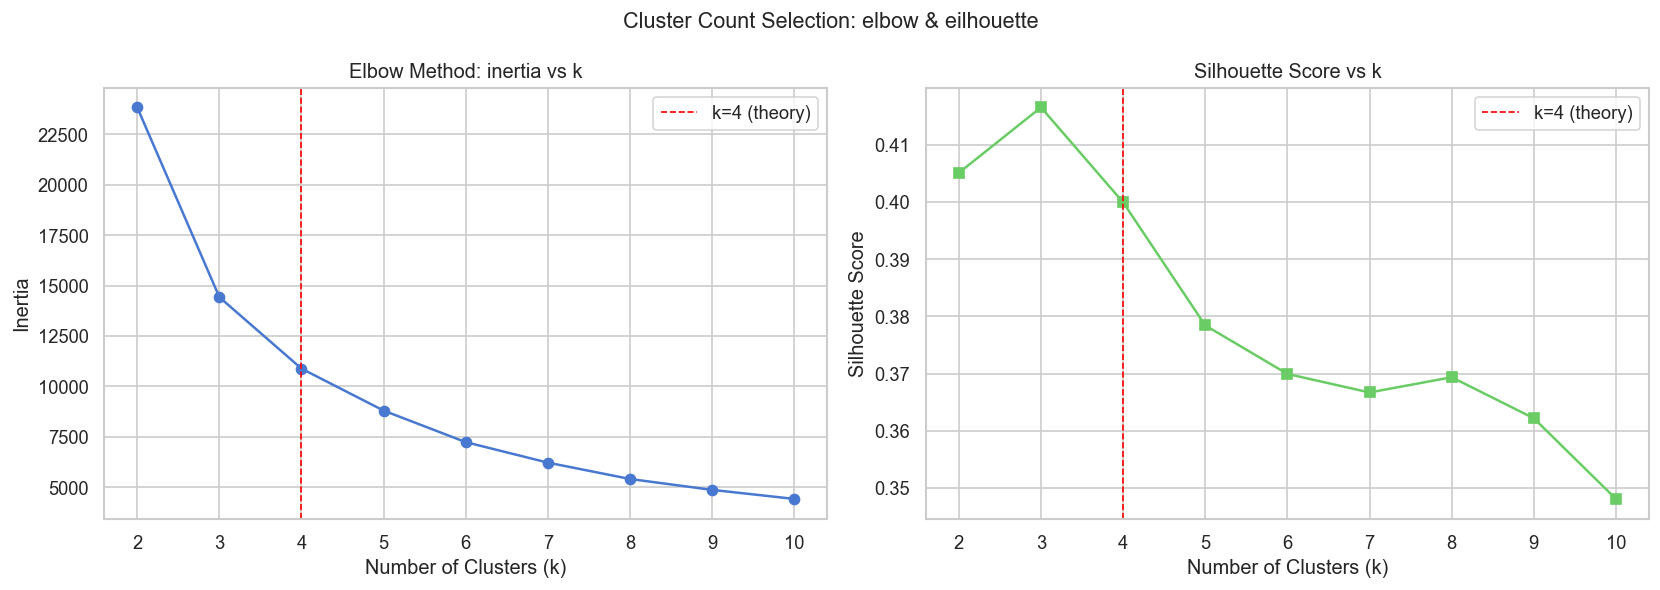

Silhouette score at k=4: 0.3999


In [7]:
valence_energy = df_full[['valence', 'energy']].dropna()
scaler_2d = StandardScaler()
VE_scaled = scaler_2d.fit_transform(valence_energy)
VE_sample = VE_scaled[:20000]
inertias = []
sil_scores = []

k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10)
    labels = km.fit_predict(VE_sample)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(VE_sample, labels))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, marker='o', color=sns.color_palette('muted')[0])
axes[0].axvline(4, color='red', linestyle='--', linewidth=1, label='k=4 (theory)')
axes[0].set_title('Elbow Method: inertia vs k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].legend()
axes[1].plot(k_range, sil_scores, marker='s', color=sns.color_palette('muted')[2])
axes[1].axvline(4, color='red', linestyle='--', linewidth=1, label='k=4 (theory)')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.suptitle('Cluster Count Selection: elbow & eilhouette', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/08_elbow_silhouette.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Silhouette score at k=4: {sil_scores[2]:.4f}")


In [8]:
km4 = KMeans(n_clusters=4, n_init=10)
df_full['kmeans_cluster'] = km4.fit_predict(VE_scaled)


centroids_scaled = km4.cluster_centers_
centroids_orig = scaler_2d.inverse_transform(centroids_scaled)
centroid_df = pd.DataFrame(centroids_orig, columns=['valence_c', 'energy_c'])
centroid_df.index.name = 'cluster_id'
print("\nCluster centroids:")
display(centroid_df.round(3))

def assign_mood_from_centroid(row):
    v, e = row['valence_c'], row['energy_c']
    if   v >= 0.5 and e >= 0.5: return 'Happy'
    elif v <  0.5 and e >= 0.5: return 'Energetic'
    elif v >= 0.5 and e <  0.5: return 'Calm'
    else:                        return 'Sad'

centroid_df['mood'] = centroid_df.apply(assign_mood_from_centroid, axis=1)
cluster_to_mood = centroid_df['mood'].to_dict()
print("\nCluster to Mood mapping:")
print(cluster_to_mood)
df_full['mood_label'] = df_full['kmeans_cluster'].map(cluster_to_mood)



Cluster centroids:


,valence_c,energy_c
cluster_id,,
0,0.749,0.812
1,0.218,0.295
2,0.291,0.815
3,0.610,0.487



Cluster to Mood mapping:
{0: 'Happy', 1: 'Sad', 2: 'Energetic', 3: 'Calm'}


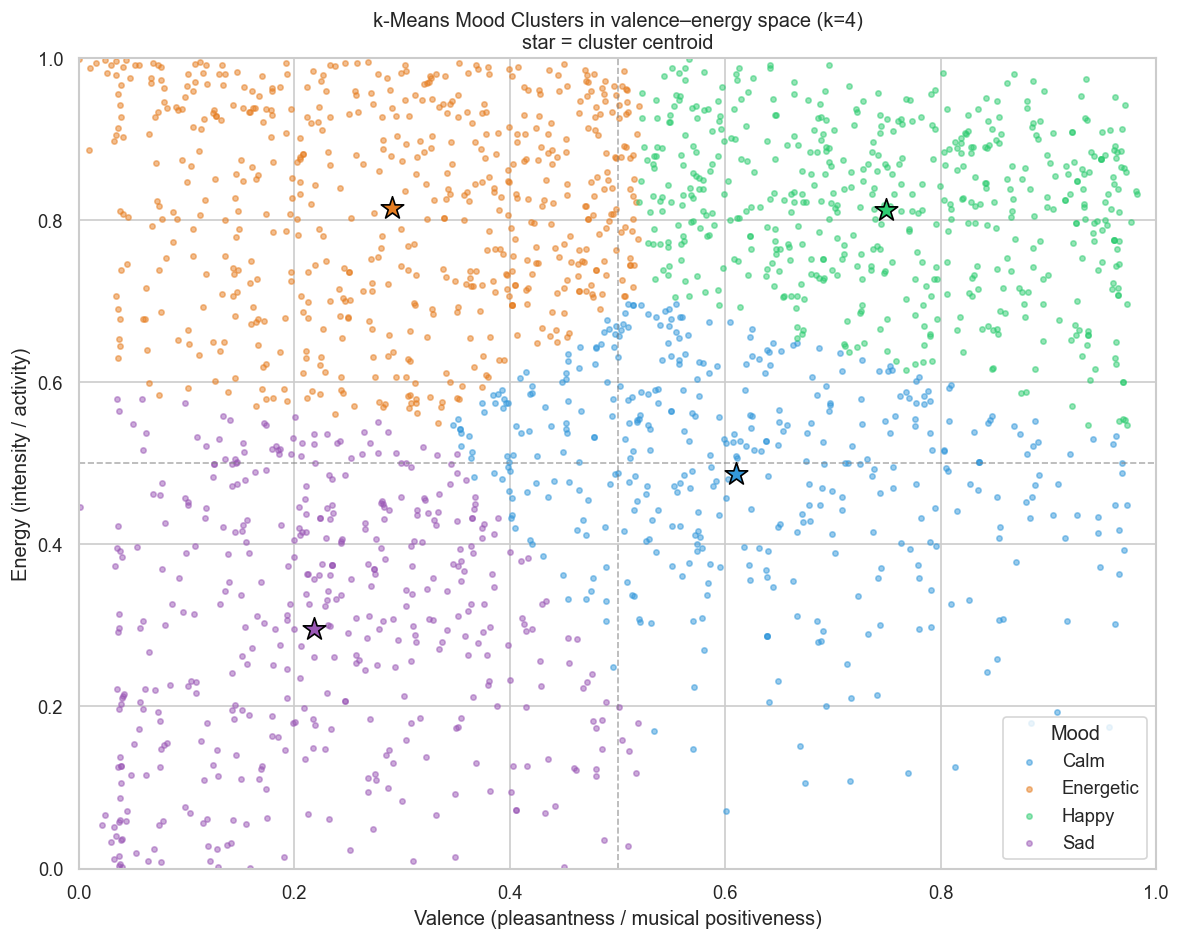

In [9]:
palette_mood = {'Happy': '#2ecc71', 'Energetic': '#e67e22',
                'Calm':  '#3498db', 'Sad':       '#9b59b6'}

sample = df_full.sample(2000)

fig, ax = plt.subplots(figsize=(10, 8))
for mood, grp in sample.groupby('mood_label'):
    ax.scatter(grp['valence'], grp['energy'], color=palette_mood[mood], alpha=0.5, s=10, label=mood)

for _, row in centroid_df.iterrows():
    ax.scatter(row['valence_c'], row['energy_c'], color=palette_mood[row['mood']], edgecolors='black', s=200, marker='*', zorder=5)

ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('Valence (pleasantness / musical positiveness)')
ax.set_ylabel('Energy (intensity / activity)')
ax.set_title('k-Means Mood Clusters in valence–energy space (k=4)\nstar = cluster centroid')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(title='Mood')
plt.tight_layout()
plt.savefig('../outputs/figures/09_kmeans_mood_clusters.png', bbox_inches='tight', dpi=150)
plt.show()




Mood Cluster Distribution:
mood_label
Energetic    34255
Happy        33339
Sad          23487
Calm         22919
Name: count, dtype: int64
mood_label
Energetic    30.05
Happy        29.24
Sad          20.60
Calm         20.10 (%)


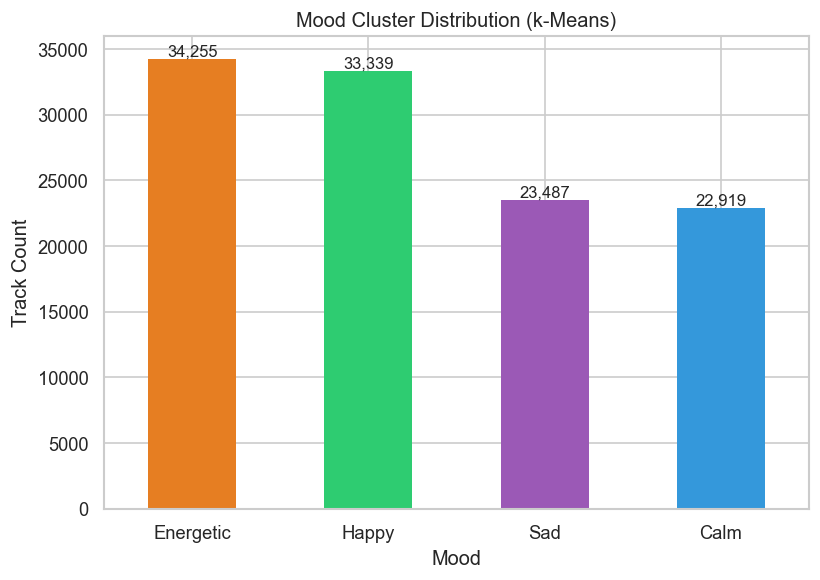

In [10]:
mood_dist = df_full['mood_label'].value_counts()
print("\nMood Cluster Distribution:")
print(mood_dist)
print(mood_dist.divide(len(df_full)).mul(100).round(2).to_string(), "(%)")

fig, ax = plt.subplots(figsize=(7, 5))
mood_dist.plot(kind='bar', ax=ax, color=[palette_mood[m] for m in mood_dist.index], edgecolor='none')
ax.set_title('Mood Cluster Distribution (k-Means)')
ax.set_xlabel('Mood')
ax.set_ylabel('Track Count')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/figures/10_mood_distribution.png', bbox_inches='tight', dpi=150)
plt.show()


K-means cluster to rule based quadrant label comparison

In [11]:
def rule_based_mood(row):
    v, e = row['valence'], row['energy']
    if v >= 0.5 and e >= 0.5: 
        return 'Happy'
    elif v < 0.5 and e >= 0.5: 
        return 'Energetic'
    elif v >= 0.5 and e < 0.5: 
        return 'Calm'
    else:
        return 'Sad'

df_full['rule_mood'] = df_full.apply(rule_based_mood, axis=1)

le  = LabelEncoder()
ari = adjusted_rand_score(le.fit_transform(df_full['rule_mood']), le.fit_transform(df_full['mood_label']))
print(f"\nAdjusted Rand Index (k-Means vs Rule-Based): {ari:.4f}")

agree_tab = pd.crosstab(df_full['rule_mood'], df_full['mood_label'], normalize='index').round(3)
print("\nNormalized agreement table (rule-based rows → k-Means columns):")
display(agree_tab)



Adjusted Rand Index (k-Means vs Rule-Based): 0.6655

Normalized agreement table (rule-based rows → k-Means columns):


mood_label,Calm,Energetic,Happy,Sad
rule_mood,,,,
Calm,0.973,0.000,0.000,0.027
Energetic,0.087,0.848,0.000,0.065
Happy,0.200,0.032,0.768,0.000
Sad,0.102,0.000,0.000,0.898


Prepare train/val/test splits with mood labels:

In [12]:
df_mood_clean = df_full[MOOD_FEATURES + ['mood_label']].dropna().reset_index(drop=True)
X_m = df_mood_clean[MOOD_FEATURES]
y_m = df_mood_clean['mood_label']

X_m_train, X_m_temp, y_m_train, y_m_temp = train_test_split(X_m, y_m, test_size=0.30, stratify=y_m)
X_m_val, X_m_test, y_m_val, y_m_test = train_test_split(X_m_temp, y_m_temp, test_size=0.667, stratify=y_m_temp)

print(f"\nMood split sizes — train: {X_m_train.shape}, val: {X_m_val.shape}, test: {X_m_test.shape}")
print("\nClass balance (train):")
print(y_m_train.value_counts(normalize=True).mul(100).round(2))

scaler_full  = StandardScaler()
X_m_train_sc = scaler_full.fit_transform(X_m_train)
X_m_val_sc   = scaler_full.transform(X_m_val)
X_m_test_sc  = scaler_full.transform(X_m_test)



Mood split sizes — train: (79800, 14), val: (11388, 14), test: (22812, 14)

Class balance (train):
mood_label
Energetic    30.05
Happy        29.24
Sad          20.60
Calm         20.10
Name: proportion, dtype: float64


Supervised classifiers on mood labels:

  Model: SVM (RBF)
  Macro F1 (5-fold): 0.9819 ± 0.0003
  Validation Accuracy : 0.9846
  Validation Macro F1 : 0.9841
  Test Accuracy       : 0.9855
  Test Macro F1       : 0.9849

  Classification Report (Test):

              precision    recall  f1-score   support

        Calm     0.9776    0.9788    0.9782      4586
   Energetic     0.9849    0.9879    0.9864      6854
       Happy     0.9916    0.9882    0.9899      6672
         Sad     0.9855    0.9847    0.9851      4700

    accuracy                         0.9855     22812
   macro avg     0.9849    0.9849    0.9849     22812
weighted avg     0.9855    0.9855    0.9855     22812

  Model: Hist Gradient Boosting
  Macro F1 (5-fold): 0.9971 ± 0.0002
  Validation Accuracy : 0.9976
  Validation Macro F1 : 0.9974
  Test Accuracy       : 0.9976
  Test Macro F1       : 0.9974

  Classification Report (Test):

              precision    recall  f1-score   support

        Calm     0.9963    0.9959    0.9961      4586
   Energetic   

,CV F1 Mean,CV F1 Std,Val Accuracy,Val Macro F1,Test Accuracy,Test Macro F1
Model,,,,,,
SVM (RBF),0.9819,0.0003,0.9846,0.9841,0.9855,0.9849
Hist Gradient Boosting,0.9971,0.0002,0.9976,0.9974,0.9976,0.9974
Random Forest,0.9906,0.0005,0.9931,0.9922,0.9924,0.9916


,CV F1 Mean,CV F1 Std,Val Accuracy,Val Macro F1,Test Accuracy,Test Macro F1
Model,,,,,,
SVM (RBF),0.981900,0.000300,0.984600,0.984100,0.985500,0.984900
Hist Gradient Boosting,0.997100,0.000200,0.997600,0.997400,0.997600,0.997400
Random Forest,0.990600,0.000500,0.993100,0.992200,0.992400,0.991600


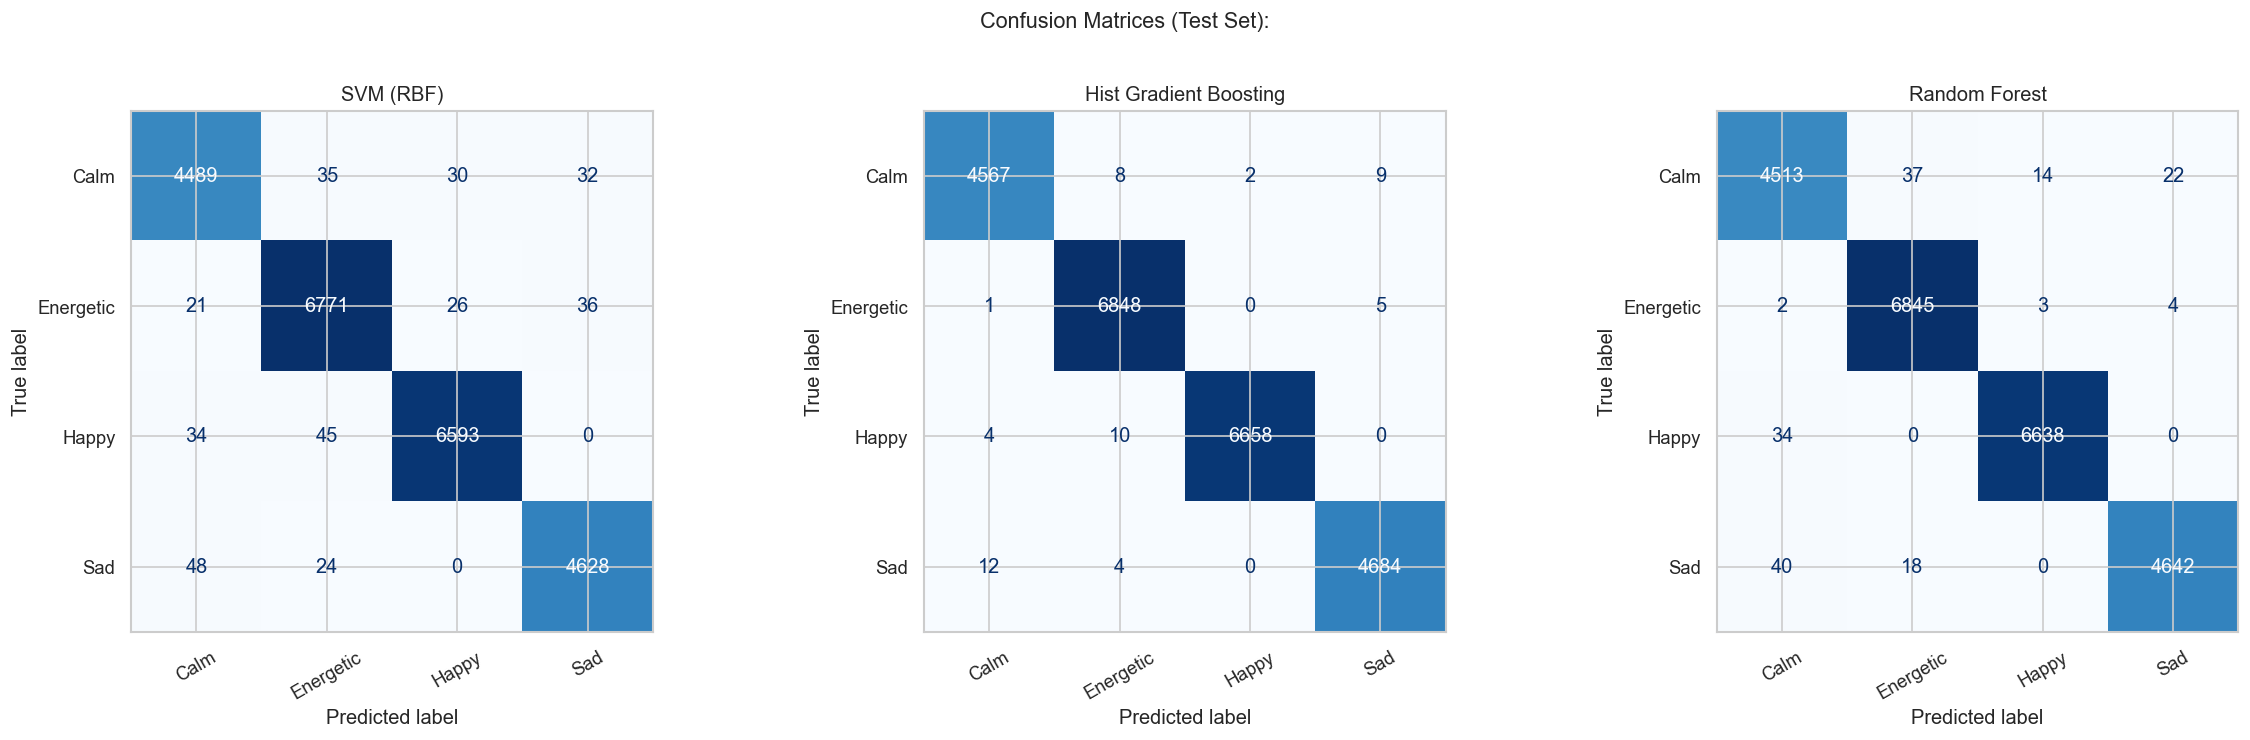

In [22]:
models = {
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, gamma='scale'),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(max_iter=200, max_depth=5, learning_rate=0.1),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=None, n_jobs=-1)
}

results_summary = []
trained_models  = {}
cv = StratifiedKFold(n_splits=5, shuffle=True)

for name, model in models.items():
    print(f"  Model: {name}")

    if 'SVM' in name:
        Xtr, Xva, Xte = X_m_train_sc, X_m_val_sc, X_m_test_sc
    else:
        Xtr = X_m_train.values
        Xva = X_m_val.values
        Xte = X_m_test.values

    cv_scores = cross_val_score(model, Xtr, y_m_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    print(f"  Macro F1 (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    model.fit(Xtr, y_m_train)
    trained_models[name] = (model, Xte)

    y_val_pred = model.predict(Xva)
    val_acc = accuracy_score(y_m_val, y_val_pred)
    val_f1 = f1_score(y_m_val, y_val_pred, average='macro')
    print(f"  Validation Accuracy : {val_acc:.4f}")
    print(f"  Validation Macro F1 : {val_f1:.4f}")

    y_te_pred = model.predict(Xte)
    test_acc = accuracy_score(y_m_test, y_te_pred)
    test_f1 = f1_score(y_m_test, y_te_pred, average='macro')
    print(f"  Test Accuracy       : {test_acc:.4f}")
    print(f"  Test Macro F1       : {test_f1:.4f}")
    print(f"\n  Classification Report (Test):\n")
    print(classification_report(y_m_test, y_te_pred, digits=4))

    results_summary.append({
        'Model': name,
        'CV F1 Mean': round(cv_scores.mean(), 4),
        'CV F1 Std': round(cv_scores.std(), 4),
        'Val Accuracy': round(val_acc, 4),
        'Val Macro F1': round(val_f1, 4),
        'Test Accuracy': round(test_acc, 4),
        'Test Macro F1': round(test_f1, 4)
    })

results_df = pd.DataFrame(results_summary).set_index('Model')
print("\n Summary Table ")
display(results_df)
display(results_df.style.background_gradient(subset=['Test Macro F1'], cmap='YlGn'))

mood_classes = sorted(y_m_test.unique())
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, (model, Xte)) in zip(axes, trained_models.items()):
    y_te_pred = model.predict(Xte)
    cm = confusion_matrix(y_m_test, y_te_pred, labels=mood_classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mood_classes)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices (Test Set):', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/11_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

Parameter tuning

In [25]:
param_grid = {
    'max_iter': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
}
gb_base = HistGradientBoostingClassifier(max_leaf_nodes=31)
grid_search = GridSearchCV(gb_base, param_grid, cv=StratifiedKFold(n_splits=3, shuffle=True), scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search.fit(X_m_train.values, y_m_train)

print(f"\nBest parameters : {grid_search.best_params_}")
print(f"Best CV F1      : {grid_search.best_score_:.4f}")

best_gb    = grid_search.best_estimator_
y_te_tuned = best_gb.predict(X_m_test.values)
tuned_acc  = accuracy_score(y_m_test, y_te_tuned)
tuned_f1   = f1_score(y_m_test, y_te_tuned, average='macro')

print(f"\nTest Accuracy : {tuned_acc:.4f}")
print(f"Test Macro F1 : {tuned_f1:.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_m_test, y_te_tuned, digits=4))

results_df.loc['Hist Gradient Boosting (Tuned)'] = {
    'CV F1 Mean': round(grid_search.best_score_, 4),
    'CV F1 Std': 0,
    'Val Accuracy': np.nan,
    'Val Macro F1': np.nan,
    'Test Accuracy': round(tuned_acc, 4),
    'Test Macro F1': round(tuned_f1, 4)
}
display(results_df)


Fitting 3 folds for each of 18 candidates, totalling 54 fits

Best parameters : {'learning_rate': 0.1, 'max_depth': 5, 'max_iter': 100}
Best CV F1      : 0.9970

Test Accuracy : 0.9974
Test Macro F1 : 0.9972

Classification Report:

              precision    recall  f1-score   support

        Calm     0.9954    0.9959    0.9956      4586
   Energetic     0.9975    0.9985    0.9980      6854
       Happy     0.9986    0.9976    0.9981      6672
         Sad     0.9972    0.9968    0.9970      4700

    accuracy                         0.9974     22812
   macro avg     0.9972    0.9972    0.9972     22812
weighted avg     0.9974    0.9974    0.9974     22812



,CV F1 Mean,CV F1 Std,Val Accuracy,Val Macro F1,Test Accuracy,Test Macro F1
Model,,,,,,
SVM (RBF),0.9819,0.0003,0.9846,0.9841,0.9855,0.9849
Hist Gradient Boosting,0.9971,0.0002,0.9976,0.9974,0.9976,0.9974
Random Forest,0.9906,0.0005,0.9931,0.9922,0.9924,0.9916
Hist Gradient Boosting (Tuned),0.9970,0.0000,NaN,NaN,0.9974,0.9972


feature importance:

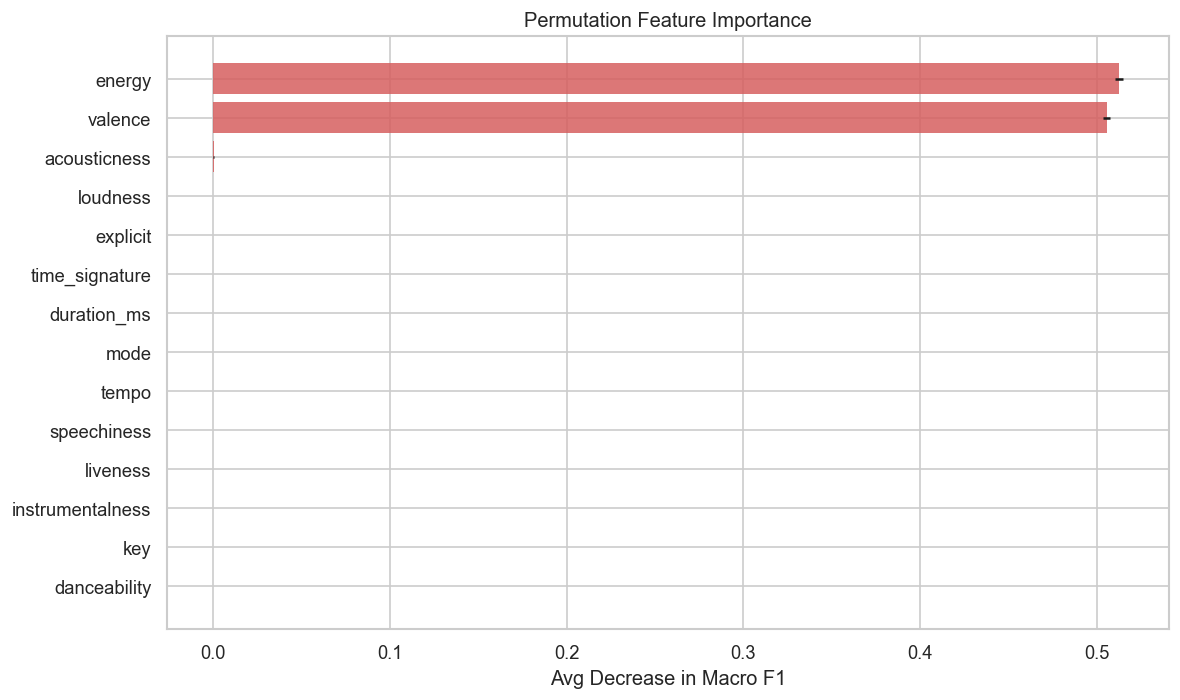


Top 5 Most Important Features:


,feature,mean_imp,std_imp
1,energy,0.5125,0.0023
7,valence,0.5054,0.0022
4,acousticness,0.0003,0.0002
2,loudness,0.0001,0.0001
13,explicit,0.0000,0.0000


In [27]:
perm_imp = permutation_importance(best_gb, X_m_test.values, y_m_test,n_repeats=10, scoring='f1_macro', n_jobs=-1)
perm_df = pd.DataFrame({
    'feature'  : MOOD_FEATURES,
    'mean_imp' : perm_imp.importances_mean,
    'std_imp'  : perm_imp.importances_std
}).sort_values('mean_imp', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_df['feature'], perm_df['mean_imp'],xerr=perm_df['std_imp'],color=sns.color_palette('muted')[3],edgecolor='none', alpha=0.85)
ax.set_title('Permutation Feature Importance')
ax.set_xlabel('Avg Decrease in Macro F1')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/figures/12_permutation_importance.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nTop 5 Most Important Features:")
display(perm_df.head(5).round(4))


Mood distribution across genres:

In [28]:
top20_by_median = (df_full.groupby('track_genre')['popularity'].median().nlargest(20).index)

df_top20 = df_full[df_full['track_genre'].isin(top20_by_median)]

mood_genre_ct = pd.crosstab(df_top20['track_genre'],df_top20['mood_label'],normalize='index').round(3)

print("\nMood Distribution Across Top 20 Genres:")
display(mood_genre_ct.style.background_gradient(cmap='YlOrRd', axis=1).format('{:.2%}'))



Mood Distribution Across Top 20 Genres:


mood_label,Calm,Energetic,Happy,Sad
track_genre,,,,
ambient,3.00%,7.20%,0.90%,88.90%
anime,8.50%,32.90%,33.60%,25.00%
british,24.40%,14.00%,21.50%,40.10%
chill,35.70%,10.30%,6.40%,47.60%
deep-house,12.00%,47.70%,32.90%,7.40%
electro,23.40%,39.20%,24.40%,13.00%
emo,22.70%,35.30%,24.10%,17.90%
grunge,4.40%,64.00%,23.90%,7.70%
hip-hop,26.40%,26.20%,39.70%,7.70%


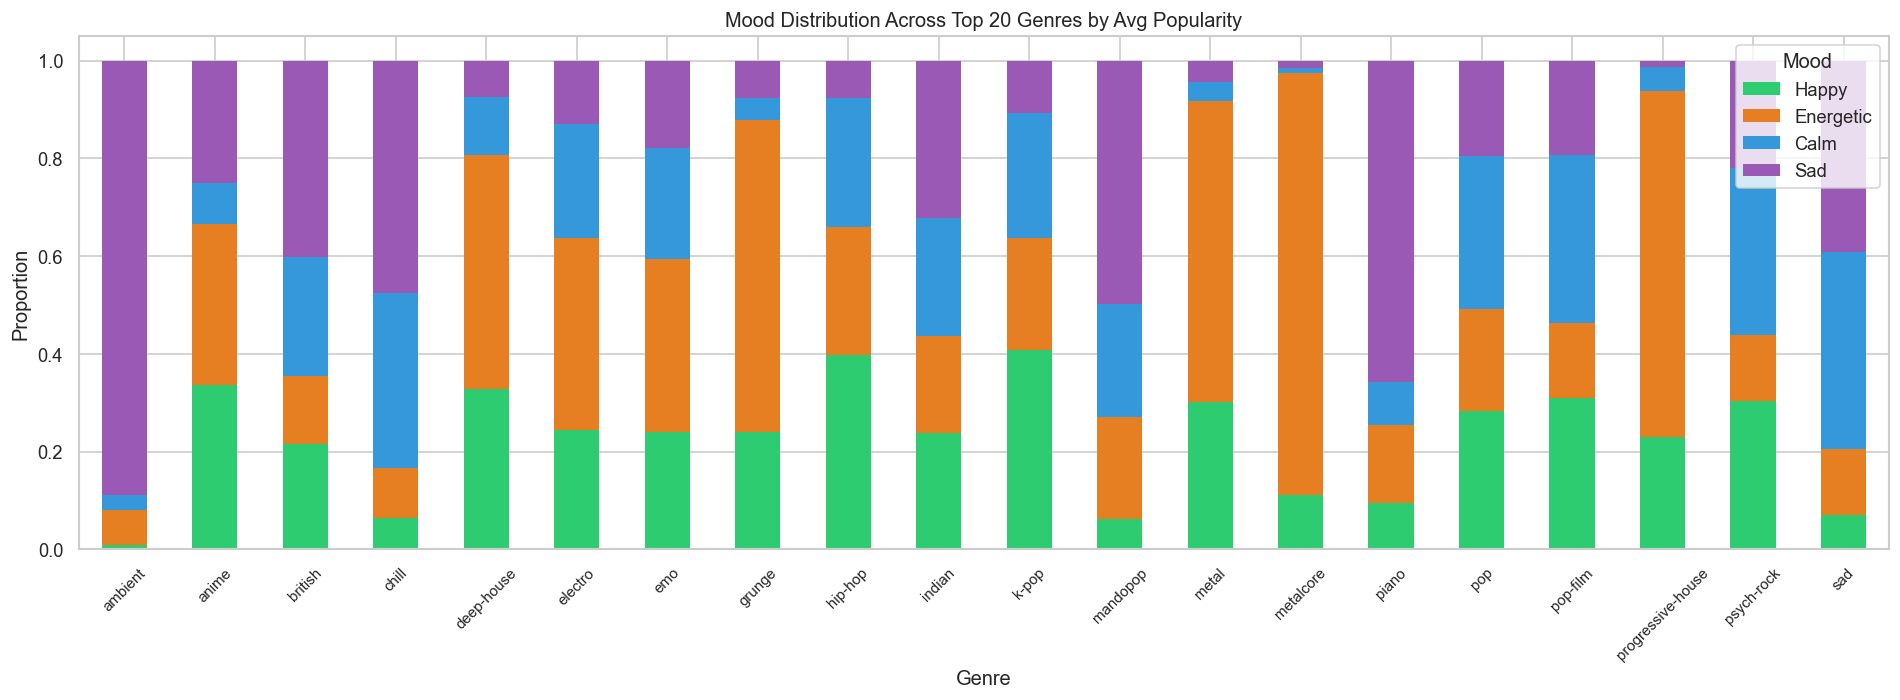

In [29]:
mood_genre_raw = pd.crosstab(df_top20['track_genre'], df_top20['mood_label'])
mood_genre_pct = mood_genre_raw.div(mood_genre_raw.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(16, 6))
mood_genre_pct[['Happy', 'Energetic', 'Calm', 'Sad']].plot(kind='bar', stacked=True, ax=ax, color=[palette_mood[m] for m in ['Happy', 'Energetic', 'Calm', 'Sad']], edgecolor='none')
ax.set_title('Mood Distribution Across Top 20 Genres by Avg Popularity')
ax.set_xlabel('Genre')
ax.set_ylabel('Proportion')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.legend(title='Mood', loc='upper right')
plt.tight_layout()
plt.savefig('../outputs/figures/14_mood_by_genre_stacked.png', bbox_inches='tight', dpi=150)
plt.show()


In [31]:
chi2_stat, p_val, dof, expected = chi2_contingency(mood_genre_raw)

print(f"\nChi-Square Test (Mood x Genre):")
print(f"  chi2 = {chi2_stat:.2f},  df = {dof},  p = {p_val:.4e}")
if p_val < 0.05:
    print("  Reject H0. Mood distribution differs significantly across genres (p < 0.05).")
else:
    print("  Fail to reject H0. Mood distribution does not differ significantly across genres.")



Chi-Square Test (Mood x Genre):
  chi2 = 9715.57,  df = 57,  p = 0.0000e+00
  Reject H0. Mood distribution differs significantly across genres (p < 0.05).


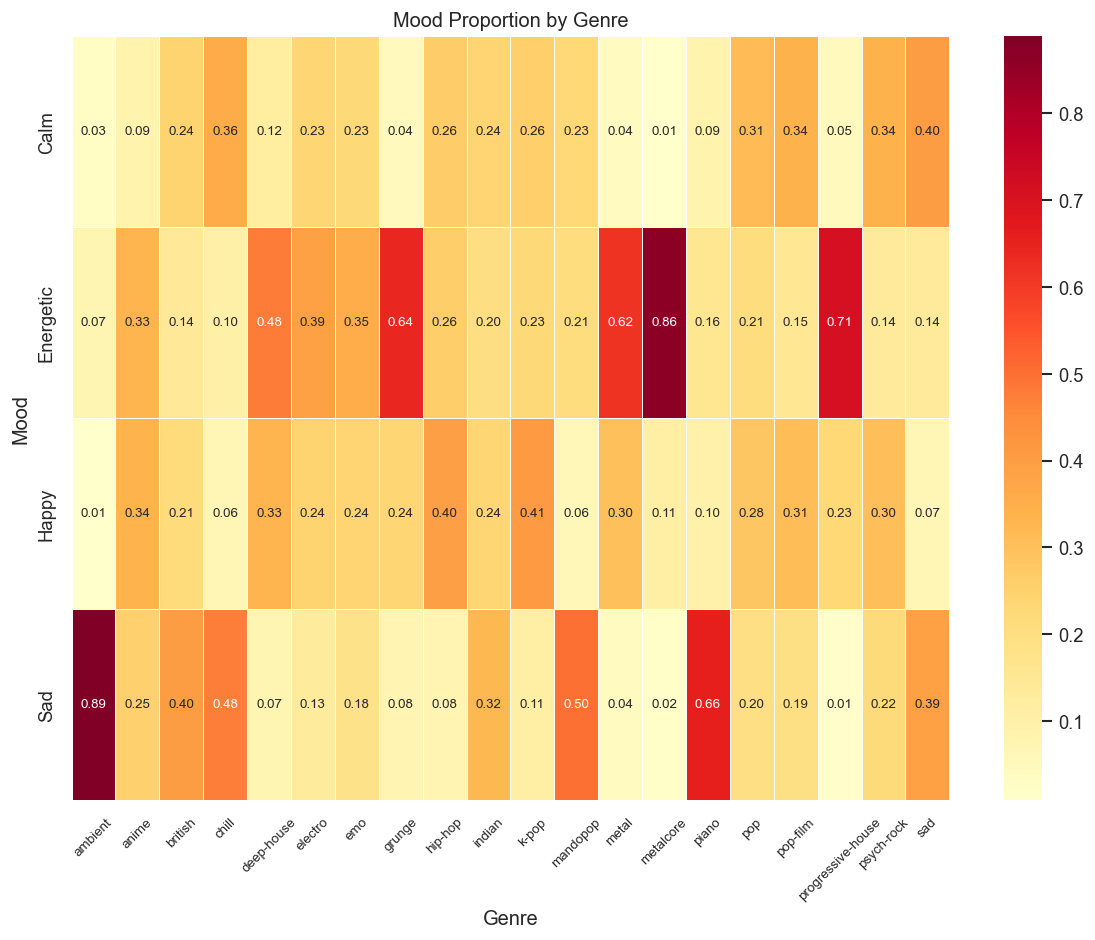

In [32]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(mood_genre_ct.T, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.4, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Mood Proportion by Genre')
ax.set_xlabel('Genre')
ax.set_ylabel('Mood')
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.savefig('../outputs/figures/15_mood_genre_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


PCA visualisation of mood clusters


Variance explained by PC1 + PC2: 32.48%


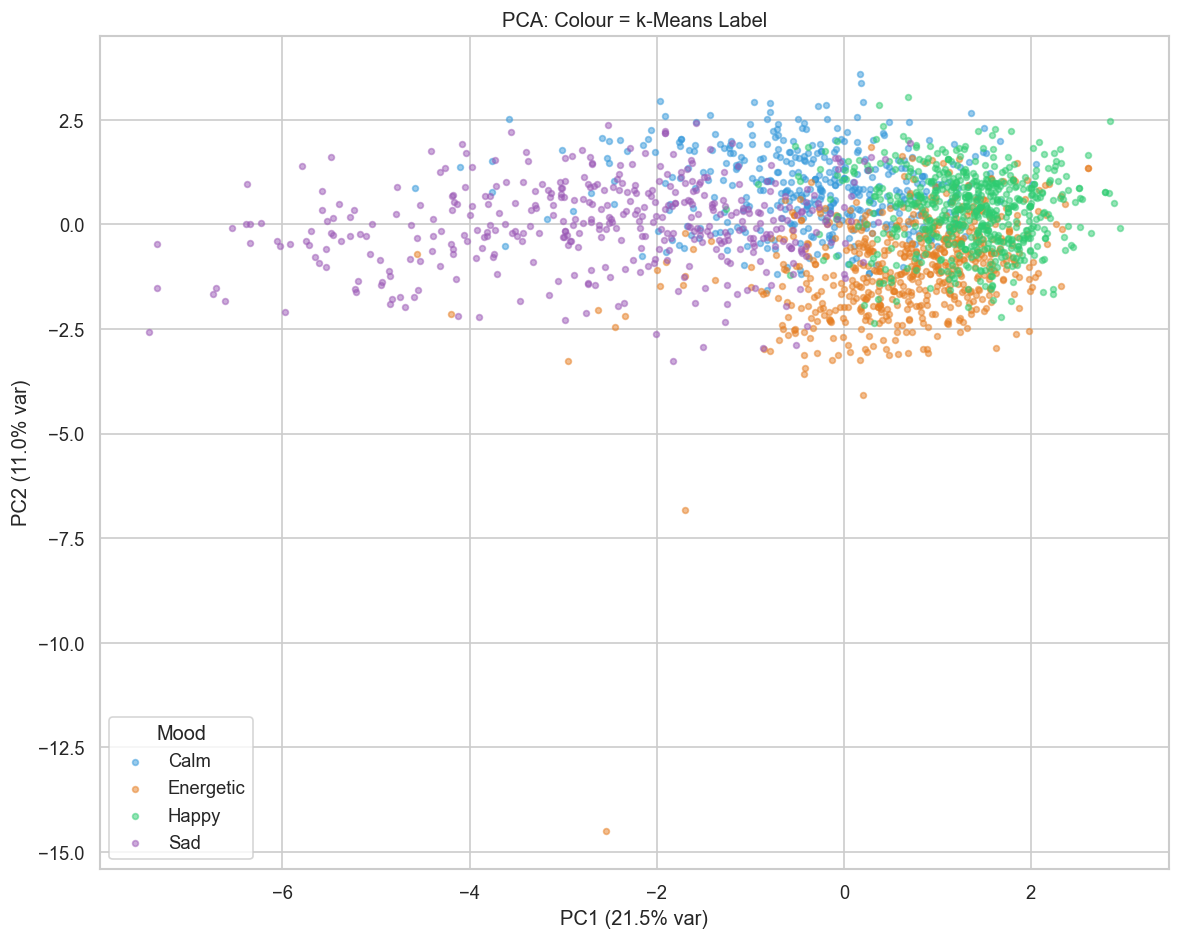

In [33]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaler_full.transform(df_mood_clean[MOOD_FEATURES]))
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['mood'] = df_mood_clean['mood_label'].values

print(f"\nVariance explained by PC1 + PC2: {pca.explained_variance_ratio_.sum()*100:.2f}%")

sample_pca = df_pca.sample(2000)
fig, ax = plt.subplots(figsize=(10, 8))

for mood, grp in sample_pca.groupby('mood'):
    ax.scatter(grp['PC1'], grp['PC2'],color=palette_mood[mood], alpha=0.5, s=12, label=mood)

ax.set_title('PCA: Colour = k-Means Label')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.legend(title='Mood')
plt.tight_layout()
plt.savefig('../outputs/figures/16_pca_mood_clusters.png', bbox_inches='tight', dpi=150)
plt.show()